# Pipeline Visualization: Input -> Canny/IP-Adapter -> Diffusion Steps -> Output

Notebook này minh hoạ end-to-end pipeline của đề tài:

1. Ảnh `x_occ` + `mask`
2. Tách `canny (masked)` cho ControlNet
3. Tách `visible reference` cho IP-Adapter
4. Chạy SD1.5 Inpainting + ControlNet + IP-Adapter
5. Lưu và hiển thị tiến trình denoise theo từng bước (latent snapshots)
6. So sánh ảnh đầu vào / GT / output

> Ghi chú: Notebook ưu tiên tính minh hoạ nên chạy 1 sample trước để debug pipeline.

In [1]:

%pip install -q -U diffusers transformers accelerate safetensors opencv-python pillow matplotlib pandas torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 104.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 107.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 102.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 1

In [5]:
# CELL 2 — Imports + config
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt

from PIL import Image
from diffusers import StableDiffusionControlNetInpaintPipeline, ControlNetModel

# --------- PATH CONFIG ---------
# Ưu tiên Kaggle path từ notebook full-eval; nếu không có thì đổi sang local path của bạn.
KAGGLE_ROOT = Path('/kaggle/input/datasets/dangvy1507/vehicle')
LOCAL_ROOT  = Path('/Users/dangvanvy/Documents/Occluded Object Reconstruction/data/vehicle')

DATASET_ROOT = KAGGLE_ROOT if KAGGLE_ROOT.exists() else LOCAL_ROOT
SYNTH_DIR    = DATASET_ROOT / 'synthetic_occ'
GT_DIR       = SYNTH_DIR / 'x_gt'
OCC_DIR      = SYNTH_DIR / 'x_occ'
MASK_DIR     = SYNTH_DIR / 'masks'
META_CSV     = SYNTH_DIR / 'metadata_synthetic_occ.csv'

# --------- MODEL CONFIG ---------
SD_MODEL_ID = 'runwayml/stable-diffusion-inpainting'
CN_MODEL_ID = 'lllyasviel/control_v11p_sd15_canny'
IP_REPO     = 'h94/IP-Adapter'
# Chỉ để tên file; subfolder sẽ set ở CELL 3
IP_WEIGHT   = 'ip-adapter-plus_sd15.bin'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32

SEED = 42
IMG_SIZE = 512
NUM_STEPS = 30
GUIDANCE = 7.5
CN_SCALE = 0.45
IP_SCALE = 0.5
CANNY_LOW = 100
CANNY_HIGH = 200
MASK_DILATE_PX = 3
PROMPT = 'a clean photo of a complete vehicle, realistic details, consistent body shape'
NEG_PROMPT = 'blurry, artifacts, distorted geometry, extra wheels, text, watermark'

assert META_CSV.exists(), f'Không tìm thấy metadata: {META_CSV}'
meta = pd.read_csv(META_CSV)
print(f'Dataset root: {DATASET_ROOT}')
print(f'Tổng sample: {len(meta):,}')
print(f'Device: {DEVICE} | DType: {DTYPE}')

Dataset root: /kaggle/input/datasets/dangvy1507/vehicle
Tổng sample: 9,999
Device: cuda | DType: torch.float16


In [7]:
# CELL 3 — Load pipeline: ControlNet + SD Inpaint + IP-Adapter
print('Loading ControlNet...')
controlnet = ControlNetModel.from_pretrained(
    CN_MODEL_ID,
    torch_dtype=DTYPE,
    use_safetensors=False,  # repo này thường phát tán .bin
)

print('Loading SD1.5 Inpainting pipeline...')
pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    SD_MODEL_ID,
    controlnet=controlnet,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False,
    use_safetensors=False,
)
pipe = pipe.to(DEVICE)

# Tối ưu nhẹ (quan trọng: chưa bật attention_slicing ở đây)
# Một số version diffusers có thể xung đột giữa SlicedAttnProcessor và IP-Adapter
try:
    pipe.enable_xformers_memory_efficient_attention()
    xformers_ok = True
except Exception:
    xformers_ok = False

# IP-Adapter (optional) — thử nhiều cấu hình vì mỗi version diffusers xử lý khác nhau
use_ip = False
ip_errors = []

for subfolder in ['models', '']:
    try:
        pipe.load_ip_adapter(
            IP_REPO,
            subfolder=subfolder,
            weight_name=IP_WEIGHT,
        )
        use_ip = True
        print(f"IP-Adapter loaded (subfolder='{subfolder or '[root]'}').")
        break
    except Exception as e:
        ip_errors.append(f"subfolder='{subfolder or '[root]'}' -> {e}")

# Chỉ fallback attention slicing sau khi thử load IP-Adapter xong
if (not xformers_ok) and (not use_ip):
    try:
        pipe.enable_attention_slicing('auto')
    except Exception:
        pass

if not use_ip:
    print('IP-Adapter load failed -> chạy không IP-Adapter.')
    for msg in ip_errors:
        print('  ', msg)

print(f'Pipeline ready | xFormers={xformers_ok} | IP-Adapter={use_ip}')

Loading ControlNet...
Loading SD1.5 Inpainting pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: h94/IP-Adapter
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


IP-Adapter loaded (subfolder='models').
Pipeline ready | xFormers=False | IP-Adapter=True


In [8]:
# CELL 4 — Helper functions (Canny masked + visible patch + plotting)
def extract_canny_masked(image_pil, mask_pil, low=CANNY_LOW, high=CANNY_HIGH, dilate_px=MASK_DILATE_PX):
    img = np.array(image_pil.convert('RGB'))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, low, high)

    mask_np = np.array(mask_pil.convert('L'))
    if dilate_px > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_px * 2 + 1, dilate_px * 2 + 1))
        mask_np = cv2.dilate(mask_np, k, iterations=1)

    # Xóa cạnh bên trong vùng bị che để ControlNet không học vật che
    edges[mask_np > 127] = 0
    return Image.fromarray(np.stack([edges] * 3, axis=2))


def extract_visible_patch(image_pil, mask_pil):
    img = np.array(image_pil.convert('RGB'))
    mask = np.array(mask_pil.convert('L'))
    vis = img.copy()
    vis[mask > 127] = 128  # neutral gray trong vùng bị che
    return Image.fromarray(vis)


def show_row(images, titles, figsize=(20, 4), cmap_flags=None):
    if cmap_flags is None:
        cmap_flags = [None] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, im, tt, cm in zip(axes, images, titles, cmap_flags):
        ax.imshow(im, cmap=cm)
        ax.set_title(tt, fontsize=10, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

sample_idx=5344 | x_occ=cars_test_07065_b1_1782.jpg | mask=cars_test_07065_b1_1782.png | x_gt=cars_test_07065_b1_1782.jpg
occlusion_ratio=0.568


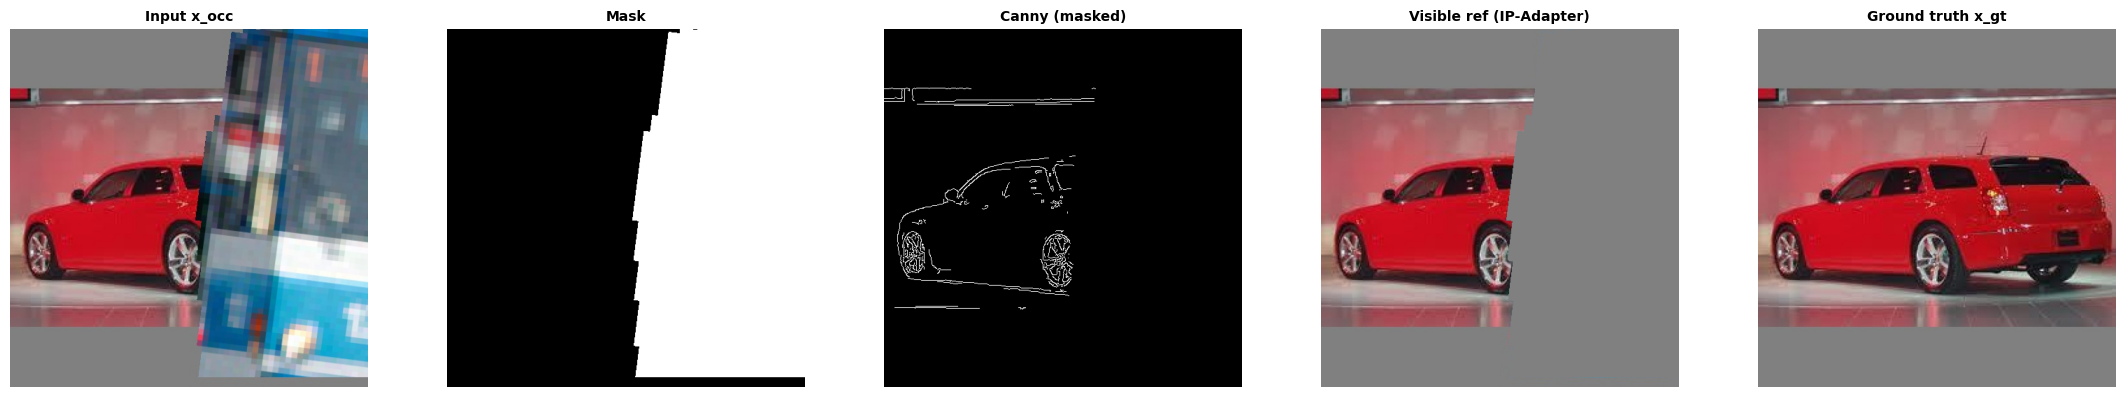

In [9]:
# CELL 5 — Chọn 1 sample và hiển thị input pipeline
# Có thể đổi sample_idx theo ý bạn
sample_idx = int(meta.sample(1, random_state=SEED).index[0])
row = meta.iloc[sample_idx]

occ = Image.open(OCC_DIR / row['x_occ']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
msk = Image.open(MASK_DIR / row['mask']).convert('L').resize((IMG_SIZE, IMG_SIZE))
gt  = Image.open(GT_DIR / row['x_gt']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

canny = extract_canny_masked(occ, msk)
visible_ref = extract_visible_patch(occ, msk)

print(f'sample_idx={sample_idx} | x_occ={row["x_occ"]} | mask={row["mask"]} | x_gt={row["x_gt"]}')
if 'occlusion_ratio' in row:
    print(f"occlusion_ratio={row['occlusion_ratio']:.3f}")

show_row(
    [occ, msk, canny, visible_ref, gt],
    ['Input x_occ', 'Mask', 'Canny (masked)', 'Visible ref (IP-Adapter)', 'Ground truth x_gt'],
    figsize=(22, 4),
    cmap_flags=[None, 'gray', None, None, None]
)

In [10]:
# CELL 6 — Xem IP-Adapter trích xuất gì (xấp xỉ qua embedding norm)
# Mục tiêu: minh hoạ rằng image reference được encode thành embedding điều kiện.
if use_ip and hasattr(pipe, 'image_encoder') and pipe.image_encoder is not None:
    try:
        # Dùng image_processor có sẵn trong pipeline nếu có
        if hasattr(pipe, 'feature_extractor') and pipe.feature_extractor is not None:
            ip_inputs = pipe.feature_extractor(images=visible_ref, return_tensors='pt').pixel_values.to(device=DEVICE, dtype=DTYPE)
        else:
            # fallback đơn giản
            arr = np.array(visible_ref).astype(np.float32) / 255.0
            arr = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
            ip_inputs = arr

        with torch.no_grad():
            feats = pipe.image_encoder(ip_inputs)

        # CLIPVisionModelWithProjection thường trả về image_embeds
        embeds = feats.image_embeds if hasattr(feats, 'image_embeds') else feats[0]
        print('IP-Adapter embedding shape:', tuple(embeds.shape))
        print('Embedding L2 norm (mean):', embeds.norm(dim=-1).mean().item())
    except Exception as e:
        print('Không trích xuất embedding trực tiếp được, nhưng visible_ref vẫn được dùng làm ip_adapter_image.')
        print('Reason:', e)
else:
    print('IP-Adapter không active hoặc pipeline không expose image_encoder.')

IP-Adapter embedding shape: (1, 1024)
Embedding L2 norm (mean): 21.6875


In [11]:
# CELL 7 — Chạy inference và capture denoise snapshots (latents -> image)
from typing import List, Dict
from contextlib import nullcontext

latent_snaps: List[Dict] = []

# Lưu snapshot tại các bước này (0-based step index)
save_steps = {0, 1, 2, 4, 7, 10, 15, 20, 25, NUM_STEPS - 1}

def callback_on_step_end(pipe, i, t, callback_kwargs):
    latents = callback_kwargs.get('latents', None)
    if latents is not None and i in save_steps:
        latent_snaps.append({
            'step': int(i),
            't': int(t.detach().cpu().item()) if torch.is_tensor(t) else int(t),
            'latents': latents.detach().float().cpu().clone(),
        })
    return callback_kwargs

# Cấu hình call
gen = torch.Generator(device=DEVICE).manual_seed(SEED)
call_kwargs = dict(
    prompt=PROMPT,
    negative_prompt=NEG_PROMPT,
    image=occ,
    mask_image=msk,
    control_image=canny,
    num_inference_steps=NUM_STEPS,
    guidance_scale=GUIDANCE,
    controlnet_conditioning_scale=CN_SCALE,
    generator=gen,
    callback_on_step_end=callback_on_step_end,
    callback_on_step_end_tensor_inputs=['latents'],
)

if use_ip:
    pipe.set_ip_adapter_scale(IP_SCALE)
    call_kwargs['ip_adapter_image'] = visible_ref

autocast_ctx = torch.autocast('cuda') if DEVICE == 'cuda' else nullcontext()
with autocast_ctx:
    out = pipe(**call_kwargs).images[0]

pred = out
print(f'Inference done. Captured {len(latent_snaps)} snapshots.')

  0%|          | 0/30 [00:00<?, ?it/s]

Inference done. Captured 10 snapshots.


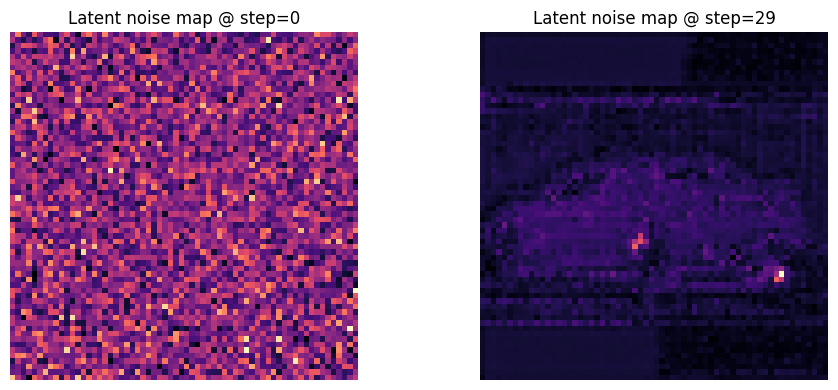

In [12]:
# CELL 8 — Minh hoạ noise/denoise trong latent space
# Ở diffusion, latent ban đầu rất nhiễu; qua các step UNet thì nhiễu giảm dần.
if len(latent_snaps) == 0:
    print('Chưa có latent snapshot. Chạy CELL 7 trước.')
else:
    first_lat = latent_snaps[0]['latents'][0]   # (C,H,W)
    last_lat  = latent_snaps[-1]['latents'][0]

    # Hiển thị norm map của latent (gợi ý mức nhiễu cấu trúc)
    first_map = first_lat.pow(2).mean(0).sqrt().numpy()
    last_map  = last_lat.pow(2).mean(0).sqrt().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(first_map, cmap='magma')
    axes[0].set_title(f'Latent noise map @ step={latent_snaps[0]["step"]}')
    axes[0].axis('off')

    axes[1].imshow(last_map, cmap='magma')
    axes[1].set_title(f'Latent noise map @ step={latent_snaps[-1]["step"]}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

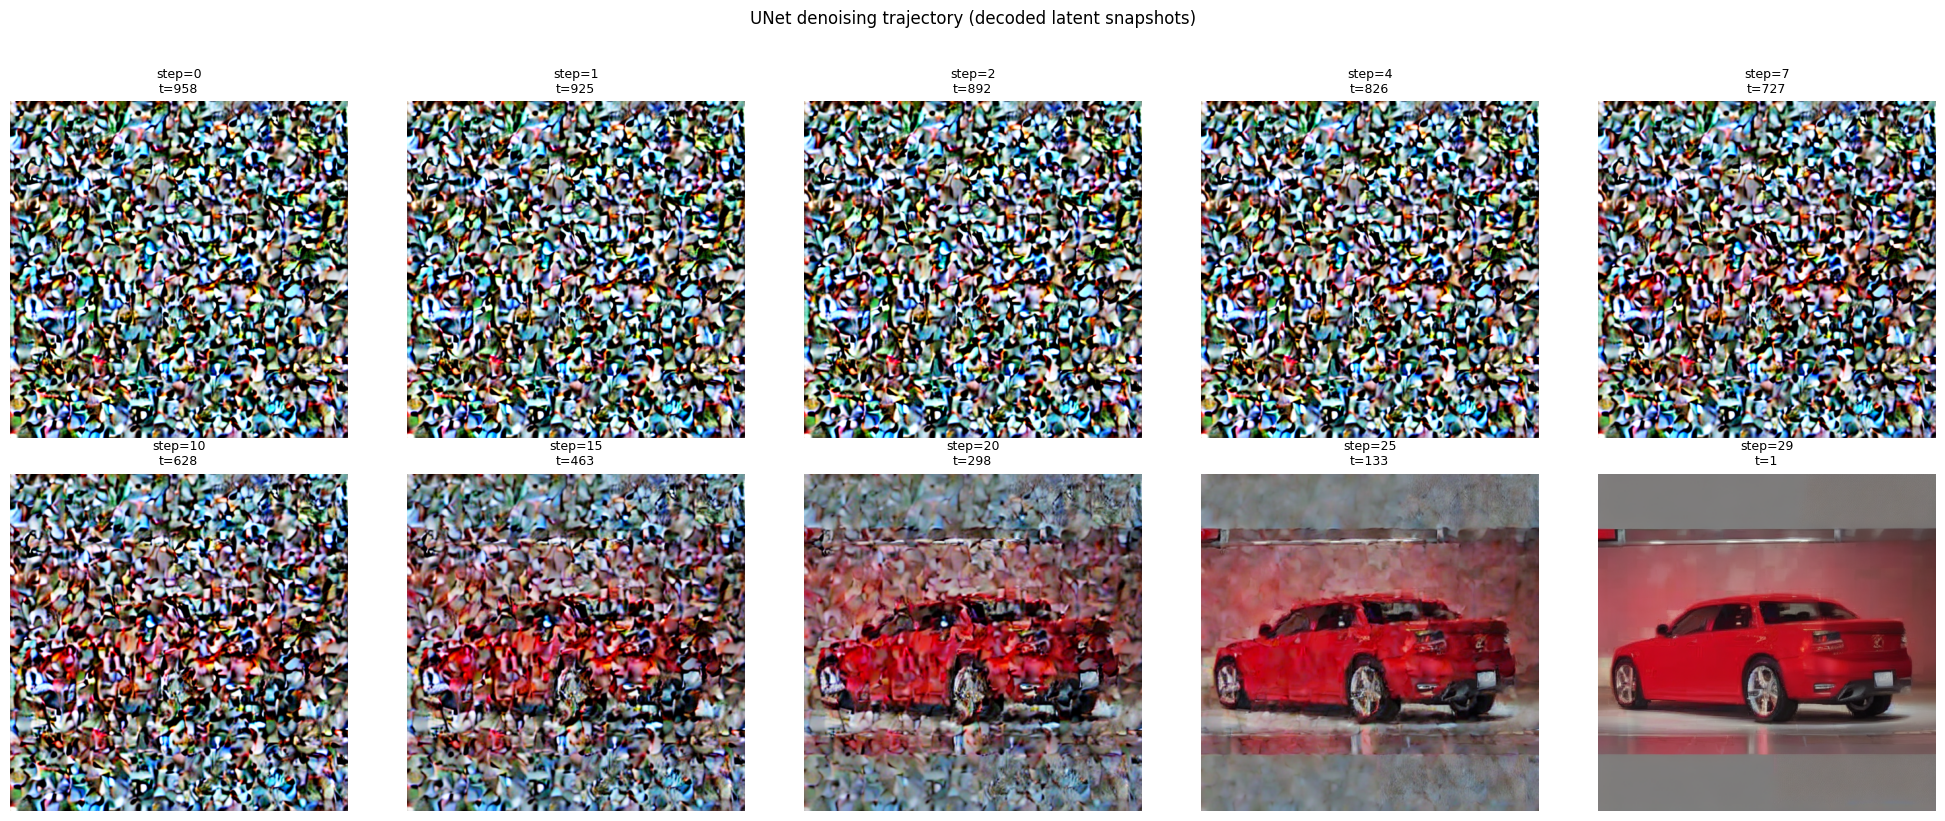

In [14]:
# CELL 8 — Decode latent snapshots thành ảnh để xem quá trình denoise
from contextlib import nullcontext


def decode_latents_to_pil(latents_cpu):
    lat = latents_cpu.to(device=DEVICE, dtype=DTYPE)
    # scale latent theo chuẩn Stable Diffusion VAE
    lat = lat / pipe.vae.config.scaling_factor
    with torch.no_grad():
        dec = pipe.vae.decode(lat).sample
    dec = (dec / 2 + 0.5).clamp(0, 1)
    dec = dec[0].permute(1, 2, 0).detach().cpu().numpy()
    dec = (dec * 255).astype(np.uint8)
    return Image.fromarray(dec)

latent_snaps = sorted(latent_snaps, key=lambda x: x['step'])
decoded_imgs = []
labels = []
for item in latent_snaps:
    decoded_imgs.append(decode_latents_to_pil(item['latents']))
    labels.append(f"step={item['step']}\nt={item['t']}")

if len(decoded_imgs) == 0:
    print('Không có snapshot nào được capture. Hãy kiểm tra callback support trong phiên bản diffusers.')
else:
    cols = min(5, len(decoded_imgs))
    rows = int(np.ceil(len(decoded_imgs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for i, (im, lb) in enumerate(zip(decoded_imgs, labels)):
        axes[i].imshow(im)
        axes[i].set_title(lb, fontsize=9)
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle('UNet denoising trajectory (decoded latent snapshots)', y=1.02)
    plt.tight_layout()
    plt.show()

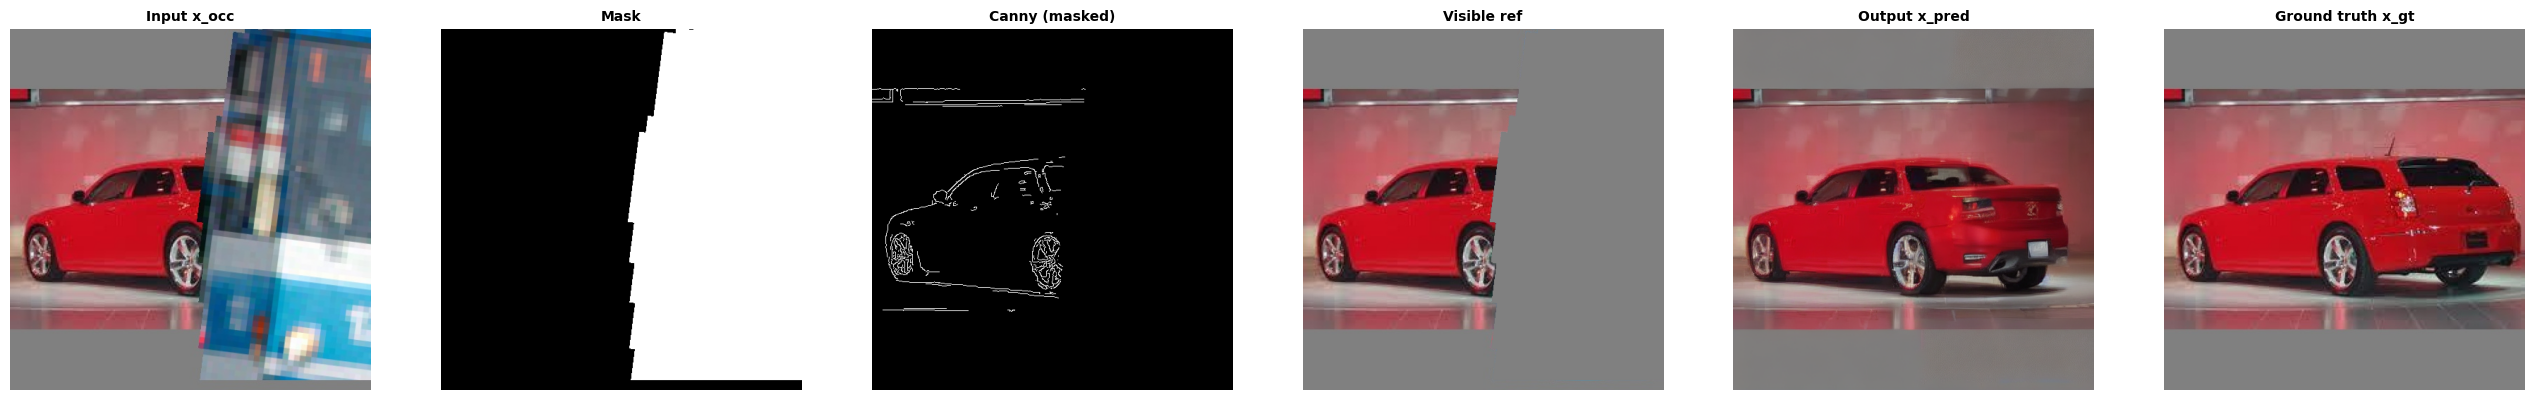

In [15]:
# CELL 9 — Hiển thị kết quả cuối cùng
show_row(
    [occ, msk, canny, visible_ref, pred, gt],
    ['Input x_occ', 'Mask', 'Canny (masked)', 'Visible ref', 'Output x_pred', 'Ground truth x_gt'],
    figsize=(26, 4),
    cmap_flags=[None, 'gray', None, None, None, None]
)

In [16]:
# CELL 10 — (Optional) Lưu toàn bộ ảnh minh hoạ ra thư mục outputs
save_dir = Path('/kaggle/working/pipeline_debug_outputs') if Path('/kaggle/working').exists() else Path('outputs/pipeline_debug_outputs')
save_dir.mkdir(parents=True, exist_ok=True)

occ.save(save_dir / '01_input_x_occ.png')
msk.save(save_dir / '02_mask.png')
canny.save(save_dir / '03_canny_masked.png')
visible_ref.save(save_dir / '04_visible_ref_ip_adapter.png')
pred.save(save_dir / '05_output_x_pred.png')
gt.save(save_dir / '06_ground_truth_x_gt.png')

for k, (im, lb) in enumerate(zip(decoded_imgs, labels)):
    im.save(save_dir / f'denoise_{k:02d}_{lb.replace(chr(10), "_").replace("=", "-")}.png')

print('Saved all visualizations to:', save_dir.resolve())

Saved all visualizations to: /kaggle/working/pipeline_debug_outputs
